# 鸢尾花分类工作

## 1.数据加载与预处理
### 使用sklearn.datasets.load_iris()加载鸢尾花数据集
### 加载数据后，将数据转化为Pandas DataFrame以便查看和操作

In [1]:
#代码
# 导入
from sklearn.datasets import load_iris
import pandas as pd

# 加载数据集
iris = load_iris()

# 转化为Pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 添加target
iris_df['target'] = iris.target

# 显示前几行数据
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2.数据可视化
### 通过Matploblib和Seaborn绘制图表
### 算法：plt.plot(), sbs.pairplot(), sbs.boxplot()等
### 操作：绘制散点图、箱型图、特征之间的关系

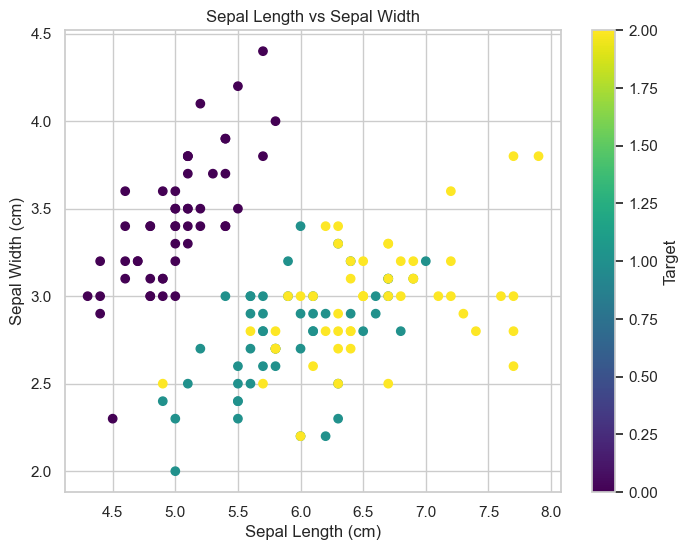

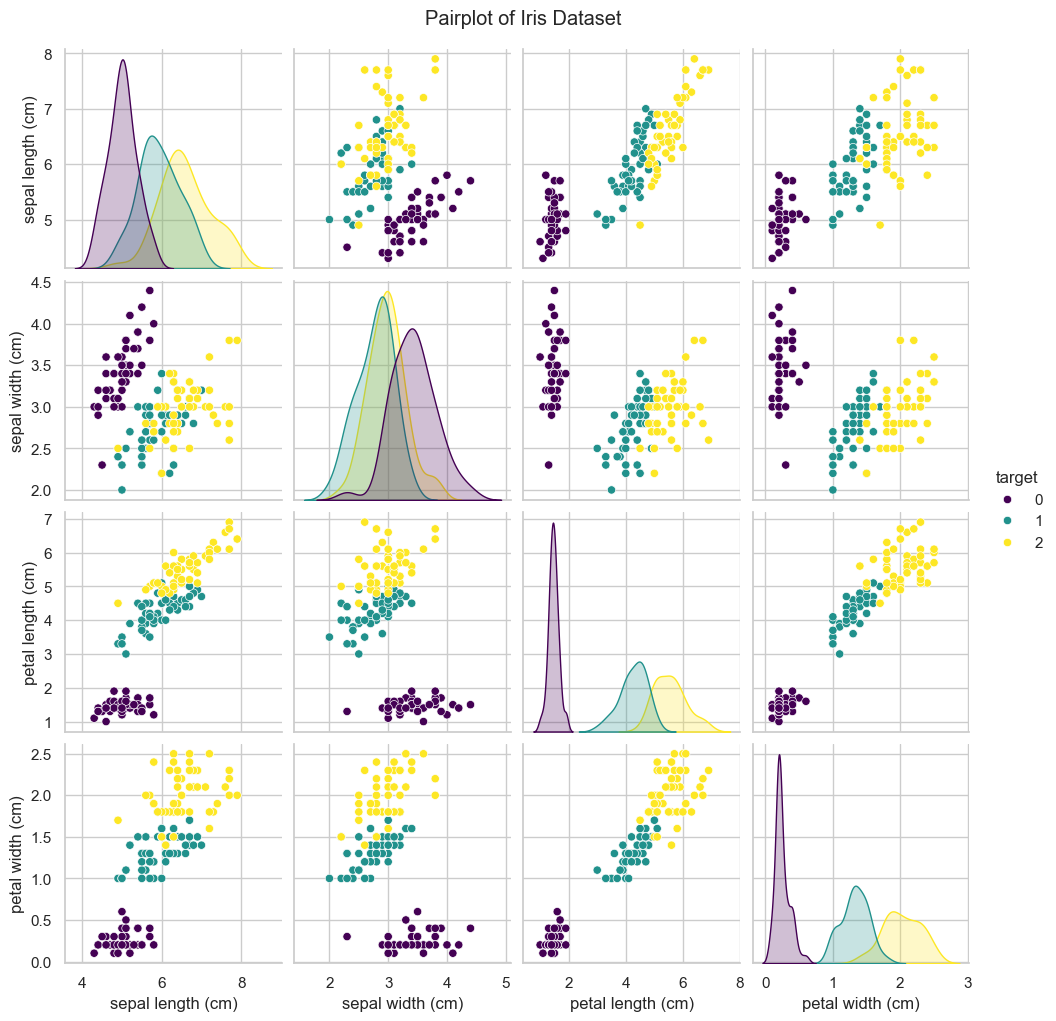

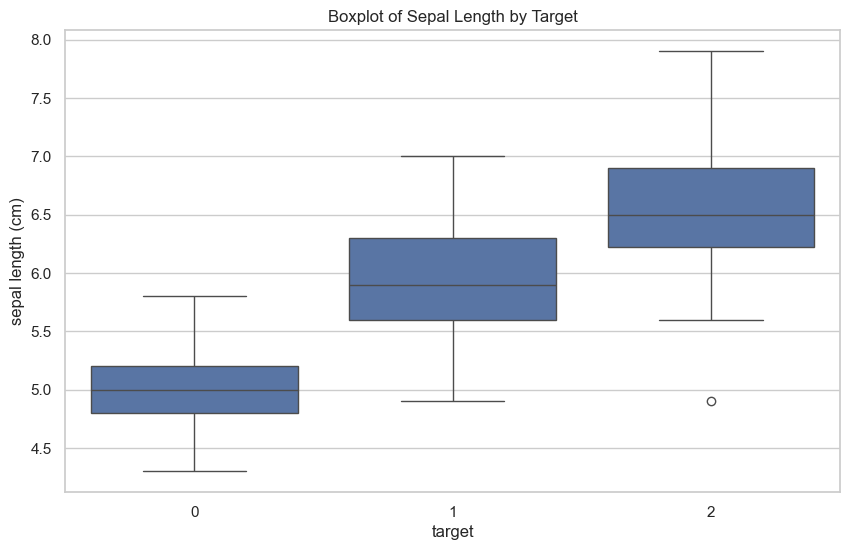

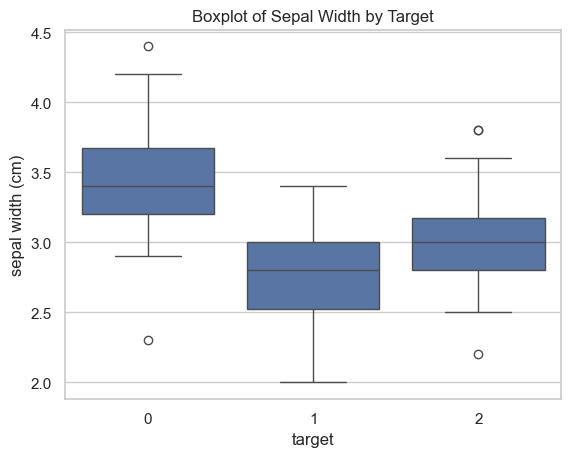

In [2]:
#代码
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Seaborn样式
sns.set(style="whitegrid")

# 1. 绘制散点图 
plt.figure(figsize=(8, 6))
plt.scatter(iris_df['sepal length (cm)'], iris_df['sepal width (cm)'], c=iris_df['target'], cmap='viridis')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.colorbar(label='Target')
plt.show()

# 2. 绘制特征之间的关系 (使用pairplot查看特征之间的关系)
sns.pairplot(iris_df, hue='target', palette='viridis')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

# 3. 绘制箱型图 (查看每个特征的分布情况)
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='sepal length (cm)', data=iris_df)
plt.title('Boxplot of Sepal Length by Target')
plt.show()

# 4. 其他特征的箱型图
sns.boxplot(x='target', y='sepal width (cm)', data=iris_df)
plt.title('Boxplot of Sepal Width by Target')
plt.show()


## 3.使用scikit-learn构建分类模型（如KNN或逻辑回归）
### 模型构建：选择K-近邻（KNN）或逻辑回归（Logistic Regression）算法
### 算法：KNeighborsClassifier()或LogisticRegression()
### 操作：划分训练集和测试集，选择模型进行训练

In [3]:
#代码
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 加载鸢尾花数据集
iris = load_iris()
X = iris.data  # 特征
y = iris.target  # 标签

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建KNN分类器对象
knn = KNeighborsClassifier(n_neighbors=3)

# 训练KNN模型
knn.fit(X_train, y_train)

# 预测测试集
y_pred_knn = knn.predict(X_test)

# 评估模型
print("KNN模型的准确率：", accuracy_score(y_test, y_pred_knn))
print("KNN分类报告：\n", classification_report(y_test, y_pred_knn))
print("KNN混淆矩阵：\n", confusion_matrix(y_test, y_pred_knn))

# 创建逻辑回归分类器对象
log_reg = LogisticRegression(max_iter=200)

# 训练逻辑回归模型
log_reg.fit(X_train, y_train)

# 预测测试集
y_pred_log_reg = log_reg.predict(X_test)

# 评估模型
print("逻辑回归模型的准确率：", accuracy_score(y_test, y_pred_log_reg))
print("逻辑回归分类报告：\n", classification_report(y_test, y_pred_log_reg))
print("逻辑回归混淆矩阵：\n", confusion_matrix(y_test, y_pred_log_reg))


KNN模型的准确率： 1.0
KNN分类报告：
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

KNN混淆矩阵：
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
逻辑回归模型的准确率： 1.0
逻辑回归分类报告：
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

逻辑回归混淆矩阵：
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## 4.评估模型性能（使用准确度、混淆矩阵等）
### 性能评估：使用准确度、混淆矩阵和分类报告评估模型
### 算法：accuracy_score(), confusion_matrix(), classification_report()
### 操作：输出模型的准确度、混淆矩阵以及分类报告。

In [4]:
#代码
from sklearn.metrics import accuracy_score

# KNN模型的准确度
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN模型的准确度：", accuracy_knn)

# 逻辑回归模型的准确度
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print("逻辑回归模型的准确度：", accuracy_log_reg)

from sklearn.metrics import confusion_matrix

# KNN模型的混淆矩阵
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("KNN混淆矩阵：\n", conf_matrix_knn)

# 逻辑回归模型的混淆矩阵
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("逻辑回归混淆矩阵：\n", conf_matrix_log_reg)

from sklearn.metrics import classification_report

# KNN模型的分类报告
class_report_knn = classification_report(y_test, y_pred_knn)
print("KNN分类报告：\n", class_report_knn)

# 逻辑回归模型的分类报告
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
print("逻辑回归分类报告：\n", class_report_log_reg)


KNN模型的准确度： 1.0
逻辑回归模型的准确度： 1.0
KNN混淆矩阵：
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
逻辑回归混淆矩阵：
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
KNN分类报告：
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

逻辑回归分类报告：
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 5.对新数据进行预测
### 新数据预测：选择模型进行新数据预测
### 算法：使用训练好的模型（KNN或逻辑回归）进行预测
### 操作：输入一个新的样本数据点，输出预测结果

In [5]:
#代码
# 假设新的样本数据点
new_data = [[5.1, 3.5, 1.4, 0.2]]  # 新样本数据点

# 使用KNN模型进行预测
prediction_knn = knn.predict(new_data)

# 输出预测结果
predicted_class_knn = iris.target_names[prediction_knn][0]
print("KNN模型预测的新数据点属于类别：", predicted_class_knn)

# 使用逻辑回归模型进行预测
prediction_log_reg = log_reg.predict(new_data)

# 输出预测结果
predicted_class_log_reg = iris.target_names[prediction_log_reg][0]
print("逻辑回归模型预测的新数据点属于类别：", predicted_class_log_reg)


KNN模型预测的新数据点属于类别： setosa
逻辑回归模型预测的新数据点属于类别： setosa
